In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam

# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from methods import evaluate_metrics


In [2]:
# generate data
T = 1000
time = torch.linspace(0, 100, T)
time_series = torch.sin(time) + torch.randn(T) * 0.1  # Signal + Noise
time_series = time_series.view(-1, 1) # Ensure [L, 1] shape

In [3]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 1), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R).squeeze(-1)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(0.1))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma), obs=targets)


In [4]:
# PARAMETERS

N_NEURONS = 100
INPUT_DIM = 1 # equals to output dim

LR = 0.005
EPOCHS = 300

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [5]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [6]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius=0.9
)


In [7]:
# Generate Torch datasets
train_ds, test_ds = construct_dataset(esn_var.reservoir, time_series, burnin=50)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [8]:
# TRAIN
history = esn_var.train(train_loader, epochs=EPOCHS)

Training Pyro ESN:   1%|          | 3/300 [00:02<03:09,  1.57it/s, Loss=23.7595]

Epoch 0 | Total ELBO Loss: 97.5341


Training Pyro ESN:  34%|███▍      | 103/300 [00:09<00:11, 16.82it/s, Loss=3.7204]

Epoch 100 | Total ELBO Loss: 3.7514


Training Pyro ESN:  68%|██████▊   | 203/300 [00:15<00:05, 17.71it/s, Loss=2.8167]

Epoch 200 | Total ELBO Loss: 2.7741


Training Pyro ESN: 100%|██████████| 300/300 [00:20<00:00, 14.48it/s, Loss=2.7465]


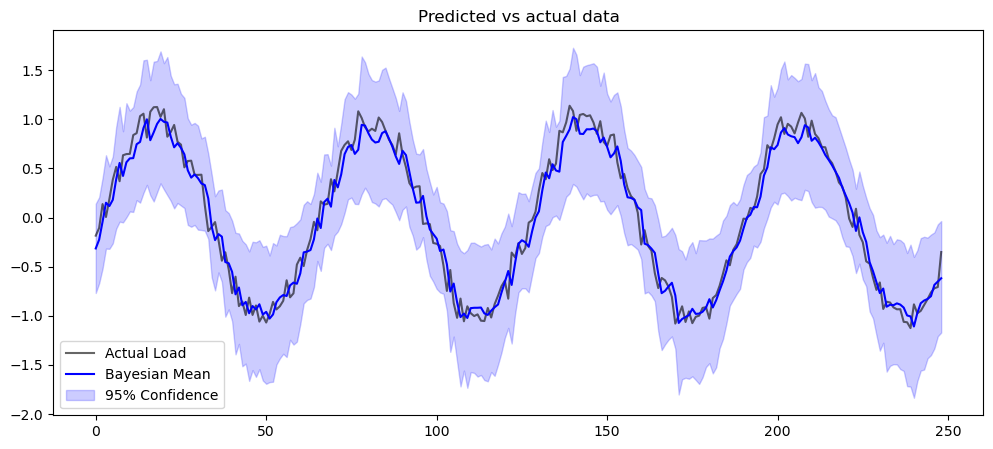

In [9]:
# PREDICT & PLOT
scaler = {'mean': train_ds.mean, 'std': train_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler)

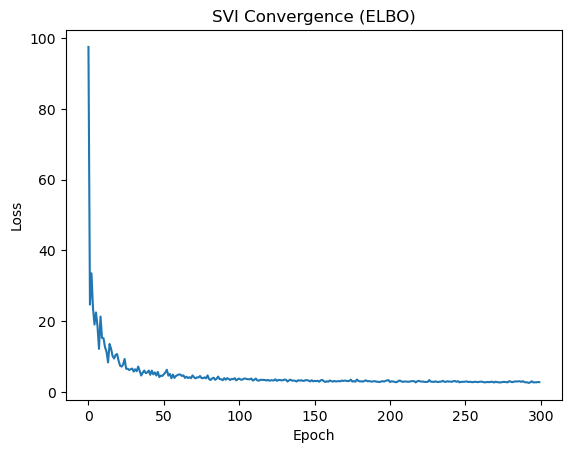

In [10]:
# Plot loss
plt.figure()
plt.plot(history)
plt.title("SVI Convergence (ELBO)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Metrics evaluation

In [11]:
ecov, cal, mcrps = evaluate_metrics(y_pred_samples=y_samples, y_true = y_true)

In [12]:
ecov, cal, mcrps

(1.0, 0.008705523712085467, 0.09381788223981857)